# Análisis Exploratorio de Datos (EDA) - Hospital El Pino

El GRD (Grupos Relacionados por el Diagnóstico) es un sistema de clasificación de pacientes. Esto quiere decir que los pacientes están asociados a códigos específicos para diagnósticos (CIE-10) y procedimientos (CIE-9). En este dataset se evalúan esos factores junto con datos demográficos básicos como la edad y el sexo, con el objetivo de predecir la categoría GRD que determina el consumo de recursos del hospital.

### Completitud de los datos  (valores nulos)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_completo = pd.read_csv('dataset_elpino.csv', sep=';')

print(f"Total de columnas: {len(df_completo.columns)}")
print(f"Total de pacientes: {len(df_completo)}")

print("\n--- LISTADO COMPLETO DE COLUMNAS ORIGINALES ---")
for i, col in enumerate(df_completo.columns):
    print(f"{i+1}. {col}")

columnas_clave = [ 'Edad en años', 'Sexo (Desc)', 'Diag 01 Principal (cod+des)','Proced 01 Principal (cod+des)',  'GRD']

df_analisis = df_completo[columnas_clave].copy()

print("\n--- MUESTRA DE LOS PRIMEROS 5 REGISTROS (DATASET FILTRADO) ---")
display(df_analisis.head())

In [ ]:
display(df_completo['Diag 02 Secundario (cod+des)'].value_counts().head(5))

display(df_completo['Diag 15 Secundario (cod+des)'].value_counts().head(5))

Durante la carga del dataset, se detectó una estructura original de 68 columnas, en la cual se pudo identicar 5 campos fundamentales los cuales son:

* Edad
* Sexo
* Diagnóstico Principal
* Procedimiento Principal
* GRD.

Las 63 columnas restantes corresponden a diagnósticos y procedimientos secundarios. Esta amplia cantidad de campos se debe a que la arquitectura de la base de datos está diseñada para soportar casos clínicos de extrema complejidad (permitiendo registrar hasta 35 diagnósticos y 30 procedimientos simultáneos por paciente).

Al realizar la limpieza de datps, se descubrió la presencia de "nulos implícitos". Probando con columnas aleatorias (como el Diagnóstico 02 y el Diagnóstico 15), se evidenció que el valor más frecuente es un guion ("-"). Esto comprueba que el sistema hospitalario rellena los espacios vacíos con este símbolo cuando el paciente no presenta más problemas.

### Correctitud y Outlayers (Precisión y valores atípicos)

In [ ]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df_analisis['Edad en años'], color='skyblue')
plt.title('Detección de Edades Atípicas')
plt.show()

df_limpio = df_analisis[(df_analisis['Edad en años'] >= 0) & (df_analisis['Edad en años'] <= 110)].dropna().copy()
print(f"Pacientes viables: {len(df_limpio)}\n")


conteo_sexo = df_limpio['Sexo (Desc)'].value_counts()
display(conteo_sexo)
suma_sexo = conteo_sexo.sum()
print(f"\ntotal de géneros: {suma_sexo}")
print(f"Total de pacientes en la base: {len(df_limpio)}")


En el análisis de valores atípicos (outliers), evaluamos nuestra variable la cual es la edad. Se evidenció que solo un registro se encontraba fuera del rango vital fisiológico establecido (0 a 110 años), el cual fue descartado del dataset.

Por otro lado, evaluamos la correctitud que evalua la veracidad y precisión de nuestras variables categóricas. Al analizar la variable Sexo del paciente, notamos que las categorías se encuentran ligeramente desbalanceadas . Sin embargo, lo más importante es que la suma de estas categorías equivale exactamente a la totalidad de los datos viables. Esto demuestra que no existen valores anómalos ni errores de tipeo.

### Análisis Genenral

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_limpio['Edad en años'], bins=30, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Distribución de Edades de los Pacientes')
axes[0].set_ylabel('Cantidad de Pacientes')

sns.countplot(data=df_limpio, x='Sexo (Desc)', ax=axes[1], palette='Set2')
axes[1].set_title('Distribución de Pacientes por Sexo')
axes[1].set_ylabel('Cantidad de Pacientes')

plt.tight_layout()
plt.show()

--- TENDENCIAS MÉDICAS PRINCIPALES ---


/tmp/ipykernel_4627/1197838212.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_diagnosticos.index, x=top_diagnosticos.values, palette='mako')


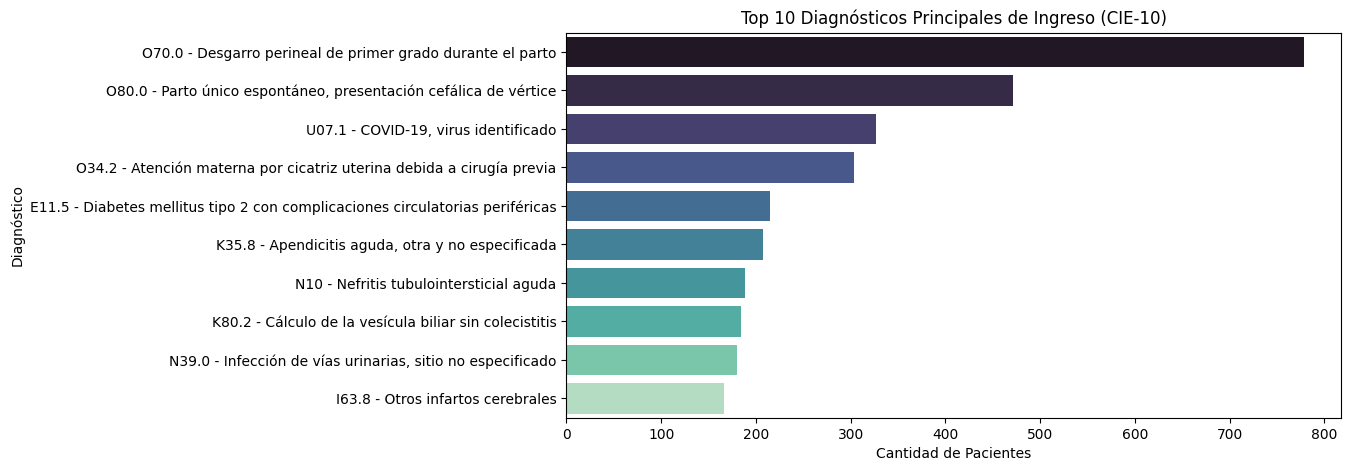

/tmp/ipykernel_4627/1197838212.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_procedimientos.index, x=top_procedimientos.values, palette='viridis')


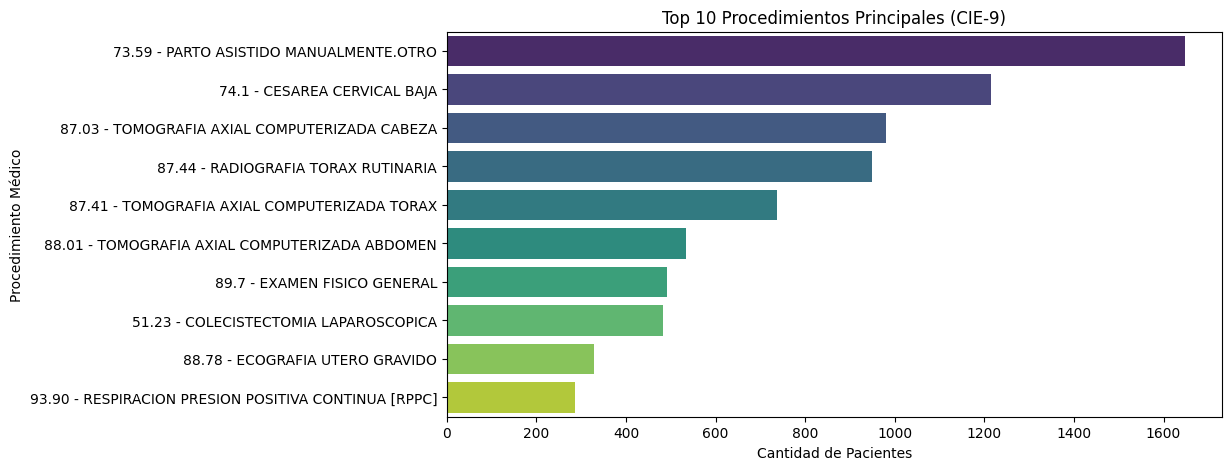

/tmp/ipykernel_4627/1197838212.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_grd.index, x=top_grd.values, palette='rocket')


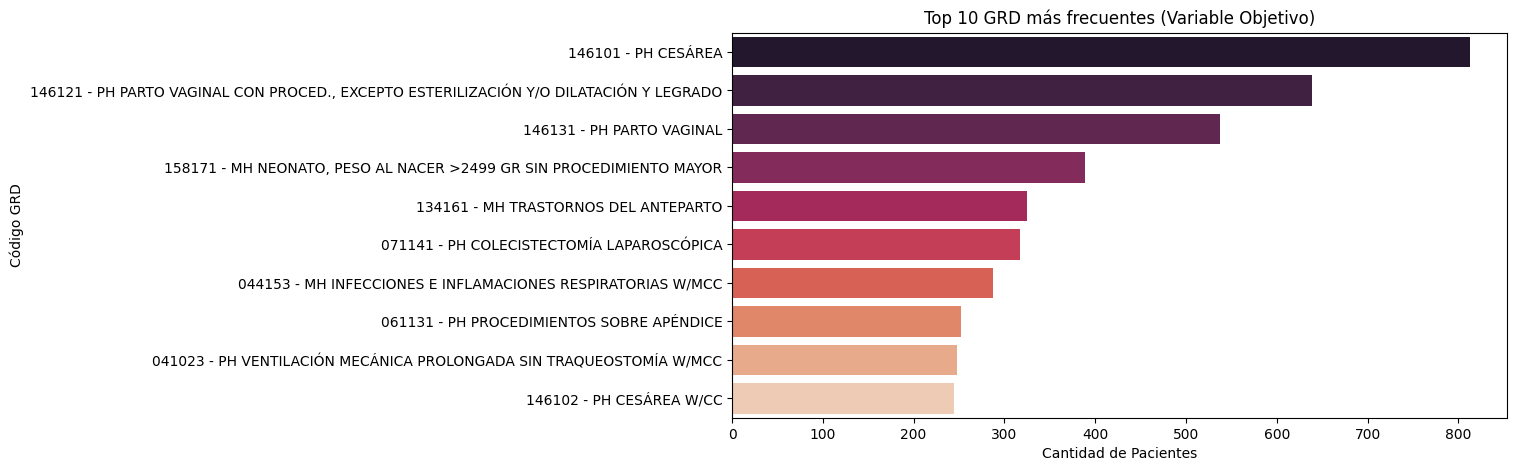

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TENDENCIAS MÉDICAS PRINCIPALES ---")

# 1. Gráfico de Diagnósticos Principales
top_diagnosticos = df_limpio['Diag 01 Principal (cod+des)'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=top_diagnosticos.index, x=top_diagnosticos.values, palette='mako')
plt.title('Top 10 Diagnósticos Principales de Ingreso (CIE-10)')
plt.xlabel('Cantidad de Pacientes')
plt.ylabel('Diagnóstico')
plt.show()

top_procedimientos = df_limpio['Proced 01 Principal (cod+des)'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=top_procedimientos.index, x=top_procedimientos.values, palette='viridis')
plt.title('Top 10 Procedimientos Principales (CIE-9)')
plt.xlabel('Cantidad de Pacientes')
plt.ylabel('Procedimiento Médico')
plt.show()

# 3. Gráfico de GRD
top_grd = df_limpio['GRD'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=top_grd.index, x=top_grd.values, palette='rocket')
plt.title('Top 10 GRD más frecuentes (Variable Objetivo)')
plt.xlabel('Cantidad de Pacientes')
plt.ylabel('Código GRD')
plt.show()

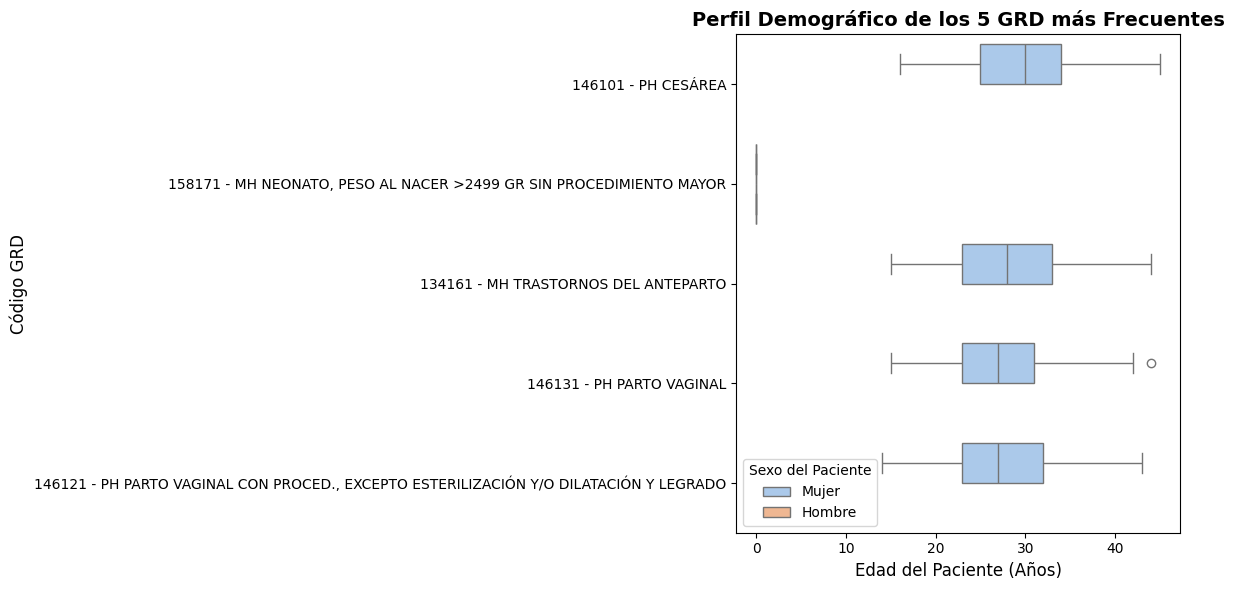

In [7]:
top5_grd = df_limpio['GRD'].value_counts().head(5).index
df_top = df_limpio[df_limpio['GRD'].isin(top5_grd)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, y='GRD', x='Edad en años', hue='Sexo (Desc)', palette='pastel')

plt.title('Perfil Demográfico de los 5 GRD más Frecuentes', fontsize=14, fontweight='bold')
plt.xlabel('Edad del Paciente (Años)', fontsize=12)
plt.ylabel('Código GRD', fontsize=12)
plt.legend(title='Sexo del Paciente')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = pd.get_dummies(df_limpio[['Edad en años', 'Sexo (Desc)', 'Diag 01 Principal (cod+des)', 'Proced 01 Principal (cod+des)']])
y = df_limpio['GRD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

predicciones = modelo_rf.predict(X_test)
exactitud = accuracy_score(y_test, predicciones)

print(f"Accuracy del modelo base es: {exactitud * 100:.2f}%")


Accuracy del modelo base es: 49.38%


/tmp/ipykernel_4627/1809242626.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso (Importancia)', y='Variable', data=df_imp, palette='magma')


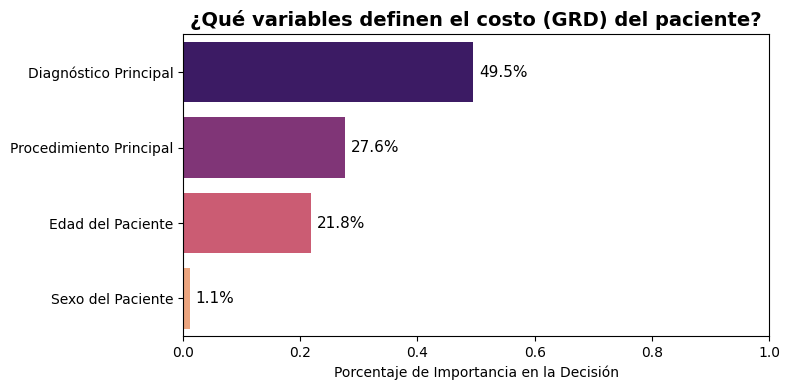

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


importancias_crudas = modelo_rf.feature_importances_
nombres_columnas = X.columns

importancia_agrupada = {
    'Edad del Paciente': 0.0,
    'Sexo del Paciente': 0.0,
    'Diagnóstico Principal': 0.0,
    'Procedimiento Principal': 0.0
}

for col, imp in zip(nombres_columnas, importancias_crudas):
    if 'Edad' in col:
        importancia_agrupada['Edad del Paciente'] += imp
    elif 'Sexo' in col:
        importancia_agrupada['Sexo del Paciente'] += imp
    elif 'Diag 01' in col:
        importancia_agrupada['Diagnóstico Principal'] += imp
    elif 'Proced 01' in col:
        importancia_agrupada['Procedimiento Principal'] += imp

df_imp = pd.DataFrame(list(importancia_agrupada.items()), columns=['Variable', 'Peso (Importancia)'])
df_imp = df_imp.sort_values(by='Peso (Importancia)', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Peso (Importancia)', y='Variable', data=df_imp, palette='magma')
plt.title('¿Qué variables definen el costo (GRD) del paciente?', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Importancia en la Decisión')
plt.ylabel('')
plt.xlim(0, 1)

for index, value in enumerate(df_imp['Peso (Importancia)']):
    plt.text(value + 0.01, index, f'{value*100:.1f}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

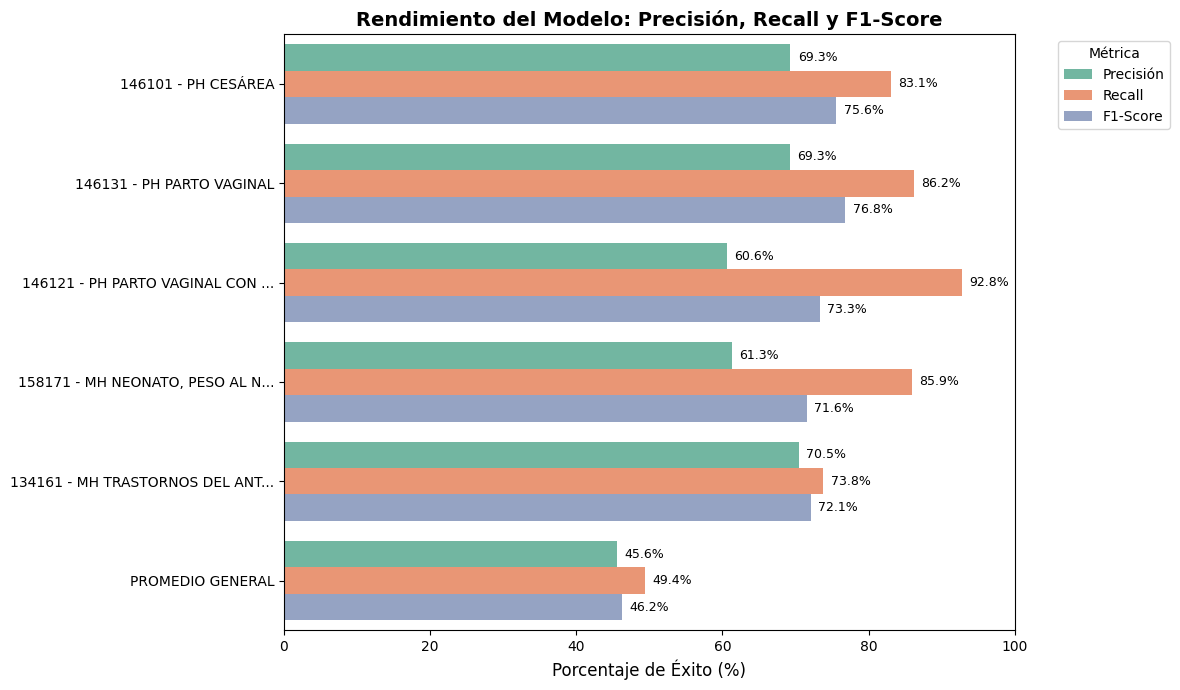

In [10]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

reporte = classification_report(y_test, predicciones, output_dict=True, zero_division=0)
top5_grd = y_test.value_counts().head(5).index.tolist()

datos_metricas = []
for grd in top5_grd:
    if grd in reporte:
        nombre_corto = grd[:30] + '...' if len(str(grd)) > 30 else str(grd)

        datos_metricas.append({'Categoría': nombre_corto, 'Métrica': 'Precisión', 'Porcentaje': reporte[grd]['precision'] * 100})
        datos_metricas.append({'Categoría': nombre_corto, 'Métrica': 'Recall', 'Porcentaje': reporte[grd]['recall'] * 100})
        datos_metricas.append({'Categoría': nombre_corto, 'Métrica': 'F1-Score', 'Porcentaje': reporte[grd]['f1-score'] * 100})

datos_metricas.append({'Categoría': 'PROMEDIO GENERAL', 'Métrica': 'Precisión', 'Porcentaje': reporte['weighted avg']['precision'] * 100})
datos_metricas.append({'Categoría': 'PROMEDIO GENERAL', 'Métrica': 'Recall', 'Porcentaje': reporte['weighted avg']['recall'] * 100})
datos_metricas.append({'Categoría': 'PROMEDIO GENERAL', 'Métrica': 'F1-Score', 'Porcentaje': reporte['weighted avg']['f1-score'] * 100})

df_metricas = pd.DataFrame(datos_metricas)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_metricas, y='Categoría', x='Porcentaje', hue='Métrica', palette='Set2')

plt.title('Rendimiento del Modelo: Precisión, Recall y F1-Score', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de Éxito (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, 100)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 1, p.get_y() + p.get_height() / 2, f'{width:.1f}%', va='center', fontsize=9)

plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###Análisis y Justificación Final del Modelo


1. Selección y Justificación del Algoritmo
El pronóstico del GRD representa un problema de Clasificación Multiclase complejo, dado que un paciente debe ser asignado a una única categoría entre cientos de opciones posibles. Inicialmente, se consideró implementar una Regresión Logística por su rapidez y eficiencia computacional; sin embargo, este algoritmo lineal presenta dificultades al manejar datos médicos complejos, relaciones no lineales y valores atípicos (outliers).

Por este motivo, se optó por un modelo Random Forest. Este algoritmo de aprendizaje en conjunto  construye múltiples Árboles de Decisión independientes y utiliza un sistema de "votación mayoritaria" para definir la predicción final. Esto nos permite capturar reglas clínicas complejas y, al promediar los resultados, evitamos el sesgo individual de un solo árbol.

2. Configuración del Baseline y Reducción de Dimensionalidad
Para nuestro modelo base (Baseline), utilizamos una configuración de 50 estimadores (Árboles) y realizamos una partición del dataset del 80% para entrenamiento y 20% para validación.

Un aspecto crítico del diseño fue la Selección de Características . Se decidió entrenar el modelo únicamente con las 5 variables principales (Edad, Sexo, Diagnóstico Principal y Procedimiento Principal). Al graficar la importancia de las variables, confirmamos que el Procedimiento y el Diagnóstico son los atributos con mayor peso predictivo. Excluir el resto de las variables secundarias fue una decisión deliberada para evitar el Sobreajuste (Overfitting). Si el modelo recibe demasiada información irrelevante o nula, tiende a memorizar los datos de entrenamiento en lugar de aprender a generalizar para pacientes nuevos.

3. Evaluación de Métricas Finales
Finalmente, al evaluar el rendimiento del modelo frente a datos desconocidos, se analizó la Precisión, el Recall y el F1-Score, prestando especial atención a los GRD más frecuentes y al promedio general ponderado (el cual se situó cercano al 46%).

Lo más destacable de nuestro Baseline es que las métricas de Precisión y Recall se encuentran equilibradas (no existe una brecha o "gap" significativo entre ellas). Esto indica que el modelo es medianamente capaz de diferenciar entre los distintos GRD sin caer en la "trampa" de sobre-predecir solo las enfermedades más comunes.

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd


# 0. LA LIMPIEZA DE COLUMNAS (¡EL FIX PARA XGBOOST!)
# XGBoost odia los símbolos raros, así que limpiamos los títulos de X_train y X_test
X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<]', '_', regex=True)

# 1. EL TRADUCTOR INTELIGENTE
codificador = LabelEncoder()
y_train_num = codificador.fit_transform(y_train)

# 2. FILTRAR DATOS ALIENÍGENAS (Enfermedades raras que no están en el entrenamiento)
mascara = y_test.isin(codificador.classes_)

X_test_filtrado = X_test[mascara]
y_test_filtrado = y_test[mascara]

# Traducimos el examen limpio
y_test_num = codificador.transform(y_test_filtrado)

# 3. CREACIÓN Y ENTRENAMIENTO DEL MODELO
print("Entrenando modelo XGBoost... (esto puede tomar unos segunditos)")
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

# A estudiar
modelo_xgb.fit(X_train, y_train_num)

# 4. EL EXAMEN FINAL
print("Evaluando pacientes de prueba...")
predicciones_num = modelo_xgb.predict(X_test_filtrado)

# Traducimos los números de vuelta a los nombres reales
predicciones_xgb = codificador.inverse_transform(predicciones_num)

# 5. SACAMOS LAS NOTAS
reporte_xgb = classification_report(y_test_filtrado, predicciones_xgb, output_dict=True, zero_division=0)
f1_xgb = reporte_xgb['weighted avg']['f1-score'] * 100

print(f" F1-Score Random Forest (Baseline) : 46.20%")
print(f"F1-Score XGBoost (Nuevo Modelo)   : {f1_xgb:.2f}%")

--- 🚀 FASE 2: ENTRENANDO XGBOOST (EL MODELO S-TIER) ---
Entrenando modelo XGBoost... (esto puede tomar unos segunditos)
